<a href="https://colab.research.google.com/github/parika8ec-hub/DA_AI_Project4-and-5_Stock_Data/blob/main/Project4_UL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Overview:

The Digits dataset from Scikit-learn is a well-known benchmark dataset used for image classification and pattern recognition tasks. It contains 1797 samples of handwritten digits (0-9), where each image is represented as an 8x8 grayscale pixel matrix, flattened into a 64-dimensional feature vector. Each pixel value ranges from 0 to 16, representing the intensity of the handwritten stroke in the image.

This dataset is widely used in machine learning because it is small, clean, and easy to interpret, making it ideal for understanding clustering and classification algorithms. Unlike large and complex image datasets, the Digits dataset allows for quick experimentation while still providing meaningful insights into pattern recognition.

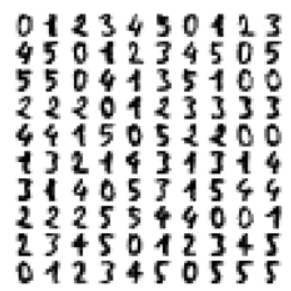

# Why choose this dataset for K-Means clustering?

- It contains naturally grouped classes (10 digits: 0-9), which makes it suitable for evaluating clustering performance.
- The dataset is unlabeled in clustering context, allowing K-Means to discover hidden structures without supervision.
- Each digit has distinct but sometimes similar visual patterns, making it a good test for evaluating how well clustering handles overlapping classes.
- The low-dimensional image size (8x8) enables easy visualization of centroids, PCA and t-SNE results.
- It helps demonstrate how unsupervised learning can extract meaningful patterns from image data without prior labels.

In [ ]:
#Import libraries
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score

# Task-1: Data Preparation and Exploration

In [ ]:
# Load Digits dataset
digits = load_digits()

X = digits.data      # images flattened already as 8x8 = 64 features
y = digits.target    # labels (0–9)

#Basic inspection to check the shape of dataset
print("Shape of X:", X.shape)
print("\nShape of y:", y.shape)
#Display unique labels in the dataset
print("\nUnique labels:", set(y))

Shape of X: (1797, 64)

Shape of y: (1797,)

Unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


In [ ]:
# Check for missing values in the dataset
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

# View dataset description
print('\nDataset Description:')
print('-'*60)
print(digits.DESCR)

Missing values in X: 0
Missing values in y: 0

Dataset Description:
------------------------------------------------------------
.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 

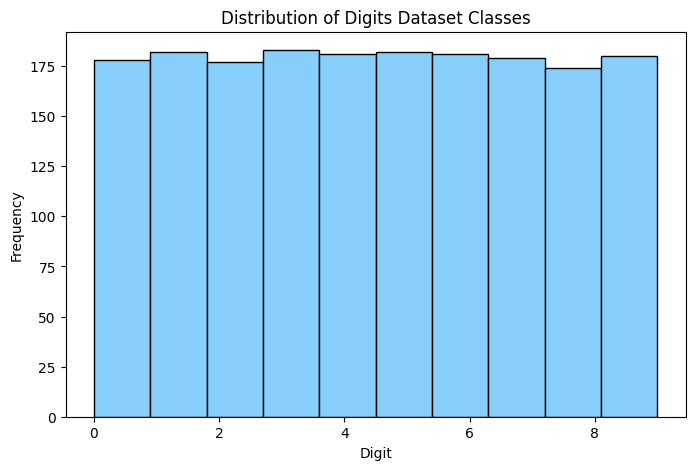

In [ ]:
# No normalization is required for the load_digits dataset because the pixel intensity values are already scaled between 0 and 16 as black and white means grayscale image
# Convert target labels to integer type for consistent processing
y = y.astype(np.int8)

# Plot the distribution of classes in the load_digits dataset to check balance across digit labels
plt.figure(figsize=(8,5))#set plot size
plt.hist(y, bins=10, edgecolor='black',color='lightskyblue')#create histogram
#Add title and label of axis
plt.title("Distribution of Digits Dataset Classes")
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.show()#display plot

**Interpretation:**

Class distribution showed that all digits are fairly balanced with each class having similar frequency.

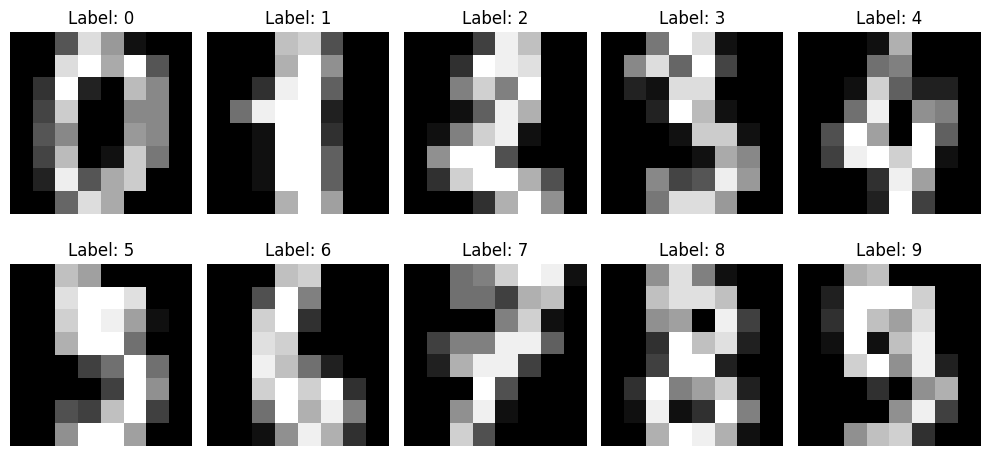

In [ ]:
# Create a figure with a 2x5 grid of subplots for displaying 10 images, with specified figure size
fig, axes = plt.subplots(2, 5, figsize=(10,5))

# Loop through each subplot axis in a flattened 1D array for easy iteration over all 10 plots
for i, ax in enumerate(axes.flat):

    # Reshape the flattened image vector back to 8x8 format and display it using a grayscale color map
    ax.imshow(X[i].reshape(8,8), cmap='gray')
    # Set the title of each subplot to show the corresponding digit label
    ax.set_title(f"Label: {y[i]}")
    # Remove axis ticks and borders for a cleaner image display
    ax.axis('off')
# Automatically adjust spacing between subplots to prevent overlap
plt.tight_layout()
#display image
plt.show()

Above plot shows the 10 images with its label as below.
- Label 0=digit 0
- Label 1=digit 1
- Label 2=digit 2
- Label 3=digit 3
- Label 4=digit 4
- Label 5=digit 5
- Label 6=digit 6
- Label 7=digit 7
- Label 8=digit 8
- Label 9=digit 9


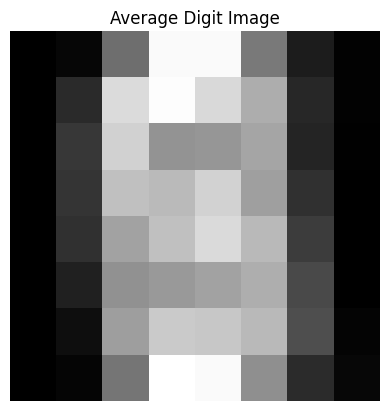

In [ ]:
# Calculate the average pixel values across all digit images
mean_image = np.mean(X, axis=0)
# Reshape the flattened average image back into 8x8 format and display it
plt.imshow(mean_image.reshape(8,8), cmap='gray')
# Add title
plt.title("Average Digit Image")
# Remove axis values for cleaner visualization
plt.axis('off')
# Display the image
plt.show()

**Interpretation:**

Mean digit image revealed a general blurred digit pattern, showing common pixel structures.

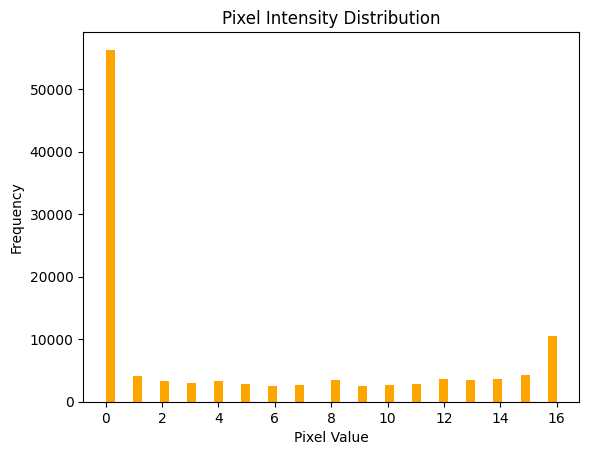

In [ ]:
# Flatten all image pixel values into a single array and plot their distribution
plt.hist(X.flatten(), bins=50,color='orange')

# Add title and label of axis
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

# Display plot
plt.show()

**Interpretation:**

Pixel intensity distribution showed most values concentrated at 0, indicating large background regions.

# Task-2: Clustering

**Note:** Elbow method is used first to determine the optimal number of clusters (K) for K-Means.Then K-Means is applied using the selected K and the resulting centroids are analyzed.

**Elbow method to find optimal number of cluster as K:**

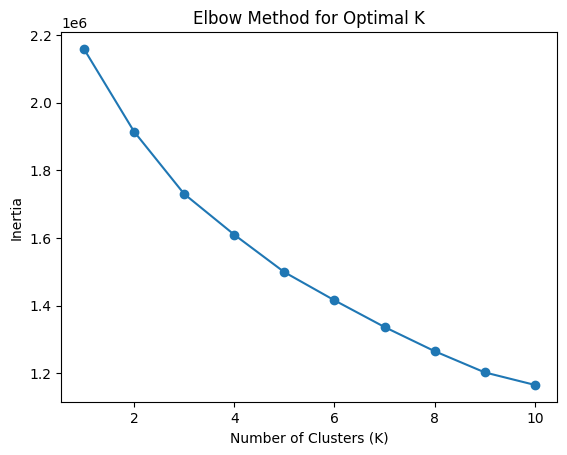

In [ ]:
# Create an empty list to store inertia values for each K value
inertias = []

# Define a range of cluster values from 1 to 10 for testing because the digits dataset contains 10 classes (0–9),
# which helps identify whether the optimal number of clusters aligns with the actual digit groups
K_range = range(1, 11)

# Train K-Means for different values of K and store inertia values
for k in K_range: #Loop through each value of K to evaluate clustering performance
    # Initialize the K-Means model with the current number of clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Train the K-Means model on the digits dataset
    kmeans.fit(X)
    # Store the inertia value for the current K
    inertias.append(kmeans.inertia_)

# Create elbow curve by plotting number of clusters against inertia values
plt.plot(K_range, inertias, marker='o')
#Add title and label of axis
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
#Display plot
plt.show()

**Insight of Elbow Curve:**

The elbow plot showed an initial bend around K = 3, but this would create broad clusters by grouping multiple digits together, making it less suitable for handwritten digit classification. Since the dataset contains 10 digit classes (0-9), a value near K = 9 or K = 10 is more appropriate. The curve begins to flatten significantly around K = 9, indicating that adding more clusters beyond this point results in only minimal improvement. Therefore, K = 9 can select as the optimal number of clusters based on the elbow method, while K = 10 is also a valid choice as it directly corresponds to the number of digit classes in the dataset, providing a more interpretable clustering structure aligned with domain knowledge.

In [ ]:
#Train K-Means with Optimal K=10

# Initialize the K-Means model with 10 clusters based on the elbow method result
kmeans = KMeans(n_clusters=10, max_iter=500, n_init=20)

# Train the model on the dataset and assign each image to its nearest cluster
clusters = kmeans.fit_predict(X)

# Calculates and prints the Silhouette Score to evaluate how well-separated the clusters are
print("Silhouette Score (KMeans):", round(silhouette_score(X, clusters),3))

Silhouette Score (KMeans): 0.182


**Interpretation:**

A silhouette score of 0.182 indicates weak cluster separation, meaning that digit clusters overlap significantly in feature space. Some points are closer to other clusters than their own. This is expected due to similarities between handwritten digits and the limitations of K-Means in handling complex high-dimensional image data.

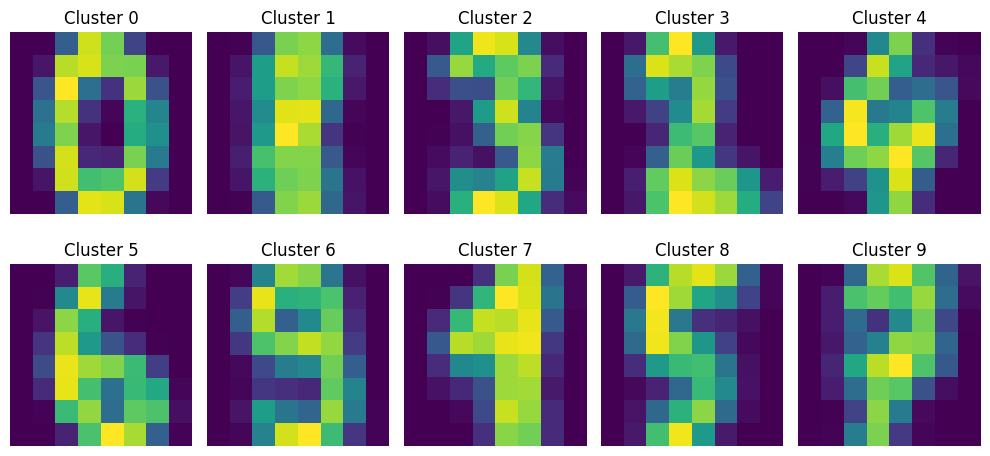

In [ ]:
# Extract cluster centroids from trained K-Means model
centroids = kmeans.cluster_centers_

# Create a 2x5 grid to display centroids (up to 10 clusters)
fig, axes = plt.subplots(2, 5, figsize=(10,5))

# Loop through each centroid and subplot
for i, ax in enumerate(axes.flat):

    # Reshape centroid into 8x8 image format
    img = centroids[i].reshape(8,8)

    # Normalize image values for better contrast visualization
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Display image using a visually distinct colormap
    ax.imshow(img, cmap='viridis')

    # Set cluster title
    ax.set_title(f"Cluster {i}")

    # Hide axis for clean visualization
    ax.axis('off')

# Adjust spacing between plots
plt.tight_layout()

# Show plot
plt.show()

**Interptretation:**

- Each centroid image represents the average of all digit images assigned to that cluster.
- The centroids highlight the dominant visual pattern of digits within each cluster.
- Some centroids clearly resemble specific handwritten digits such as 0 and 4, indicating effective clustering for those digit classes.
- Some centroids appear blurred or mixed, suggesting that visually similar digits (such as 3 and 5, 4 and 9) are grouped into the same cluster.
- This indicates that K-Means is able to capture the basic structure of digit shapes but faces difficulty distinguishing highly similar handwritten digits.
- Variations in centroid clarity show that some clusters are well-defined and pure, while others contain overlapping digit patterns.

#Task-3: Model Evaluation and Prediction

In [ ]:
#Create sample data from existing data for testing purpose

# Randomly select 300 indices to create an unseen test subset from the dataset
indices = np.random.choice(len(X), 300, replace=False)

# Extract test samples based on randomly selected indices for validation
X_test_sample = X[indices]

# Extract corresponding true labels for the selected test samples
y_test = y[indices]

# Print the shape of the test sample data
print("X_test_sample shape:", X_test_sample.shape)

# Print the shape of corresponding labels
print("y_test shape:", y_test.shape)

X_test_sample shape: (300, 64)
y_test shape: (300,)


In [ ]:
# Predicting Cluster Labels for New Data
"""
The trained K-Means model is used to assign cluster labels to new digit images using the predict() method.
Each new sample is compared to the learned centroids, and the nearest cluster is assigned based on similarity.
"""

# Assign cluster labels to new/unseen digit data
new_clusters = kmeans.predict(X_test_sample)

# Validation on Separate Data
"""
To validate the model, a separate subset of digit images is used.
The predicted cluster assignments are analyzed to check whether visually similar digits are grouped consistently
with the learned cluster centroids.
"""

# Predict cluster assignments for validation data
test_clusters = kmeans.predict(X_test_sample)

# Create an empty dictionary to store mapping from each cluster to its most common digit
cluster_to_digit = {}

# Loop through all clusters (0 to 9) to analyze digit distribution in each cluster
for cluster in range(10):
    # Find most common digit in each cluster
    most_common_digit = np.bincount(y_test[test_clusters == cluster]).argmax()#Count frequency of each digit in the current cluster and select the digit with highest frequency
    # Store the mapping of cluster ID to its most frequent digit
    cluster_to_digit['cluster '+ str(cluster)] = int(most_common_digit)
# Display the final mapping of clusters to predicted digit labels
print('Display Cluster with Actual digit: ')
print('-'*160)
print(cluster_to_digit)

Display Cluster with Actual digit: 
----------------------------------------------------------------------------------------------------------------------------------------------------------------
{'cluster 0': 0, 'cluster 1': 8, 'cluster 2': 3, 'cluster 3': 2, 'cluster 4': 4, 'cluster 5': 6, 'cluster 6': 9, 'cluster 7': 1, 'cluster 8': 5, 'cluster 9': 7}


**Evaluate result on unseen data:**

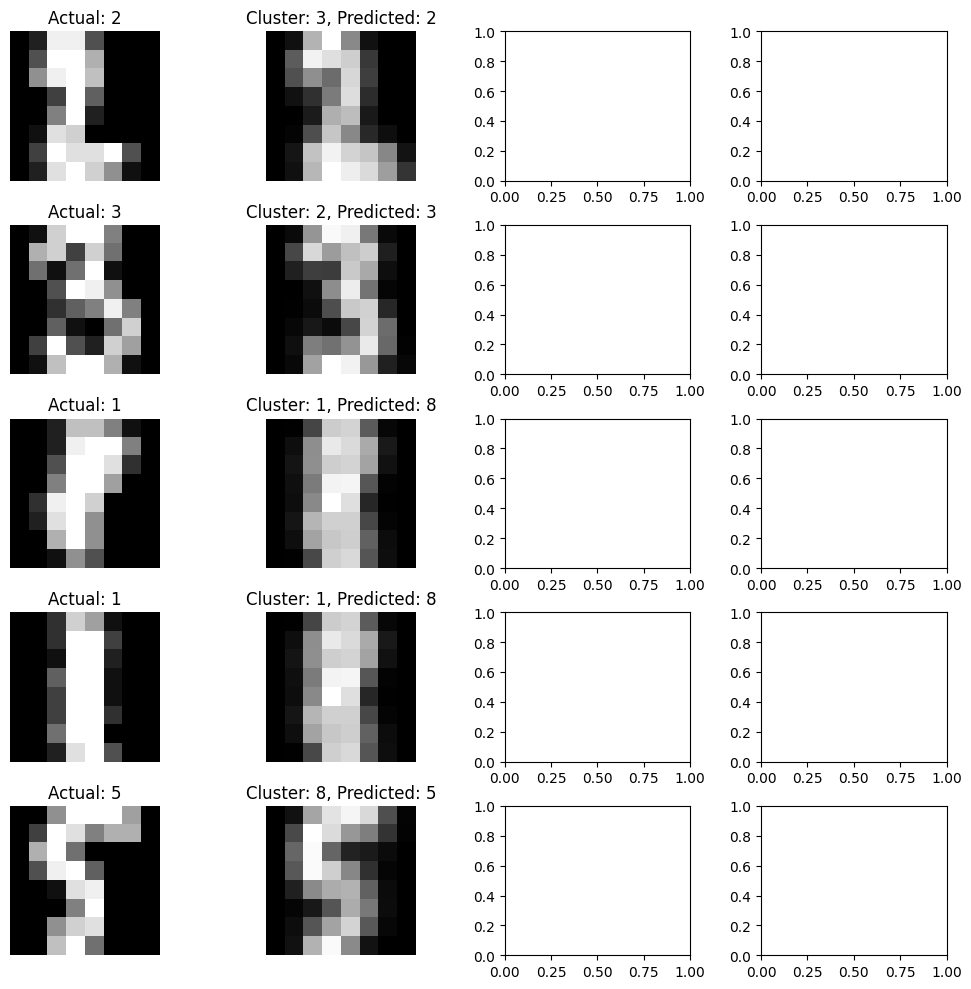

In [ ]:
#Create a 5x4 grid of subplots to display actual images and their corresponding cluster centroids side by side.
fig, axes = plt.subplots(5, 4, figsize=(10,10))
# Loop through first 5 test samples for visualization
for i in range(5):
    # Actual image
    axes[i,0].imshow(X_test_sample[i].reshape(8,8), cmap='gray') # Display the actual handwritten digit image after reshaping it to 8x8 format

    # Set title to show the true digit label
    axes[i,0].set_title(f"Actual: {y_test[i]}")

    #Remove axis ticks for cleaner visualization
    axes[i,0].axis('off')
    # Predicted cluster centroid
    axes[i,1].imshow(kmeans.cluster_centers_[test_clusters[i]].reshape(8,8), cmap='gray')#Display the centroid (average image) of the predicted cluster
    # Show predicted cluster number as title
    axes[i,1].set_title(f"Cluster: {test_clusters[i]}, Predicted: {cluster_to_digit['cluster '+str(test_clusters[i])]}")
    # Remove axis ticks for cleaner visualization
    axes[i,1].axis('off')

# Adjust spacing between subplots to avoid overlap
plt.tight_layout()
plt.show() #display plot

In [ ]:
# Compute similarity between true digit labels and predicted cluster labels
score = adjusted_rand_score(y_test, test_clusters)

# Print the ARI score rounded to 3 decimal places for easier interpretation
print("Adjusted Rand Index:", round(score, 3))#Adjusted Rand Index metric used to evaluate clustering performance against true labels

Adjusted Rand Index: 0.703


**Interptretation:**

- The Adjusted Rand Index (ARI) indicates good clustering performance.
- It shows that the model has captured meaningful structure in the digit dataset.
- The clustering results demonstrate that digits are generally grouped into appropriate clusters.However, some overlap exists due to the similarity between certain handwritten digits (e.g. 1 vs 8).
- This overlap affects perfect separation of all digit classes.
- On unseen data, the model is able to assign samples to relevant clusters based on similarity, but cluster labels do not directly correspond to actual digit labels due to the unsupervised nature of K-Means.


#Task-4: Dimensionality Reduction and Visualization using PCA and t-SNE

**i) Dimensionality Reduction Using PCA**

Explained variance ratio: [0.14890594 0.13618771]
Total variance captured: 0.28509364823699285


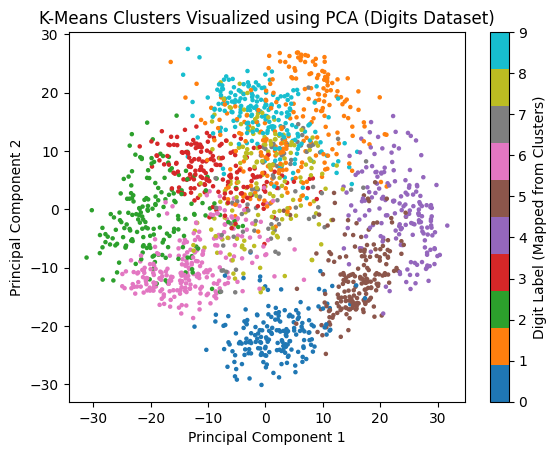

In [ ]:
# Reduce the 64-dimensional digit data to 2 principal components for visualization
pca = PCA(n_components=2)

# Fit PCA on the digit dataset and transform it into 2D space
X_pca = pca.fit_transform(X)

# Print PCA information (important insight)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

# Plot the data points in 2D space, colored according to their K-Means cluster assignments
scatter=plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=5)

# Add title and labels
plt.title("K-Means Clusters Visualized using PCA (Digits Dataset)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Add colorbar with digit labels
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Digit Label (Mapped from Clusters)")

# Display plot
plt.show()

**Interpretation:**

- The first principal component (PC1) explains 14.89% of the variance, capturing the most significant variation in the data.
- The second principal component (PC2) explains 13.62% of the variance, capturing additional variation.
- Together, both components capture only 28.5% of the total variance, meaning most information is lost in 2D projection.
- Due to low variance retention, some overlapping between clusters is expected in the visualization.
- The 2D plot still helps in understanding the general grouping and structure of digit clusters.
- Well-separated clusters in the plot indicate clear digit patterns, while overlapping regions indicate similar digits.
- Overall, PCA provides a useful but simplified representation of the high-dimensional digit dataset.


**ii) Dimensionality Reduction Using t-SNE**

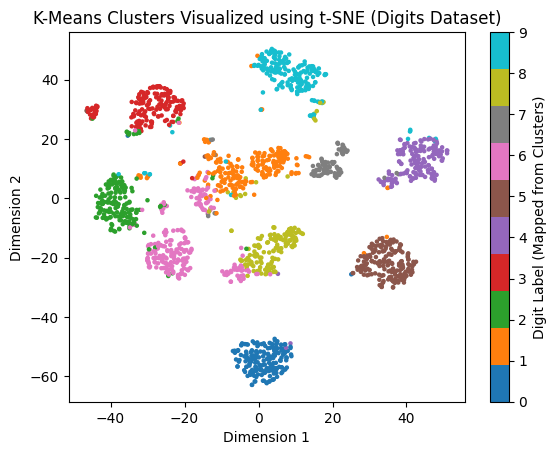

In [ ]:
# Initialize t-SNE to reduce high-dimensional digit data into 2D for visualization while preserving local structure
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Apply t-SNE transformation on the digit dataset to obtain 2D embeddings
X_tsne = tsne.fit_transform(X)

# Plot the 2D t-SNE points, colored based on K-Means cluster assignments
scatter=plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='tab10', s=5)

#Add title and label of axis
plt.title("K-Means Clusters Visualized using t-SNE (Digits Dataset)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# Add colorbar with digit labels
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("Digit Label (Mapped from Clusters)")

plt.show()#Display plot

**Interpretation:**

- Compared to PCA, t-SNE provides better separation of clusters, making digit groupings more visually distinct.
- The plot shows that similar digits are grouped closely together, indicating that local structure is well preserved.
- Clear cluster formations can be observed, showing that K-Means has identified meaningful groupings in the dataset.
- Some overlap between clusters still exists due to similarity between certain handwritten digits.
- Overall, t-SNE provides a more visually interpretable representation of the clustering structure compared to PCA.
- It helps in understanding how well the K-Means algorithm has grouped similar digit patterns in reduced 2D space.
